# FRBlip quick start

In [1]:
import numpy as np
import pymp
import frblip as frb
import matplotlib.pyplot as plt

## Create a mock of Cosmic Bursts

In [2]:
import frblip as frb

# input_main_name = 'bingo'
# input_array_name = 'naked_horn'
days = 1
zmax = 1.0 
spectral_index = -1.5
seed = 42

# telescopes = {}
# telescopes['MAIN'] = frb.telescope(input_main_name)
# telescopes['ARRAY'] = frb.telescope(input_array_name)

# main_location = telescopes['MAIN'].location

mock = frb.blips(random_state=seed, duration=days, zmax=zmax, spectral_index=spectral_index, size=2000)
# mock.observe(telescopes, verbose=False, location=main_location)
# mock.interferometry('MAIN', 'ARRAY', overwrite=True)
# mock.interferometry('ARRAY', 'ARRAY', overwrite=True)

In [3]:
mock.redshift
mock.extra_galactic_dm
mock.dispersion_measure
mock.galactic_dm
mock.igm_dm
mock.host_dm
mock.__dict__.keys()

dict_keys(['duration', 'zmin', 'zmax', 'log_L0', 'log_Lstar', 'phistar', 'gamma', 'w_mean', 'w_std', '_spec_idx_dist', 'ra_range', 'dec_range', 'low_frequency', 'high_frequency', 'low_frequency_cal', 'high_frequency_cal', 'igm_model', 'free_electron_bias', 'cosmology', 'host_dist', 'host_source', 'host_model', 'emission_frame', 'start', 'gal_nside', 'gal_method', 'random_state', 'size', 'rate', 'params', 'spectral_index', '_cosmology', '_zdist', 'redshift', 'luminosity_distance', '_xmin', '_lumdist', 'log_luminosity', '_luminosity', 'flux', '_energy_normalization', '_igm_dm', 'igm_dm', '_host_dm', 'host_dm', 'extra_galactic_dm', 'icrs', '_gal_dm', 'galactic_dm', 'dispersion_measure'])

In [4]:
"""mock.observe(telescopes, verbose=False)
mock.interferometry('MAIN', 'ARRAY')"""

"mock.observe(telescopes, verbose=False)\nmock.interferometry('MAIN', 'ARRAY')"

The results are storage on observations property:

In [5]:
frb_data = mock.catalog()

In [6]:
len(frb_data['redshift'])

2000

In [7]:
z = frb_data['redshift']
# flux = frb_data['flux']
# dl = frb_data['luminosity_distance']
DM_IGM = frb_data['igm_dm']
DM_HG = frb_data['host_dm']
DM_EG = frb_data['extra_galactic_dm']
DM = (DM_EG - DM_IGM) * (1+z)

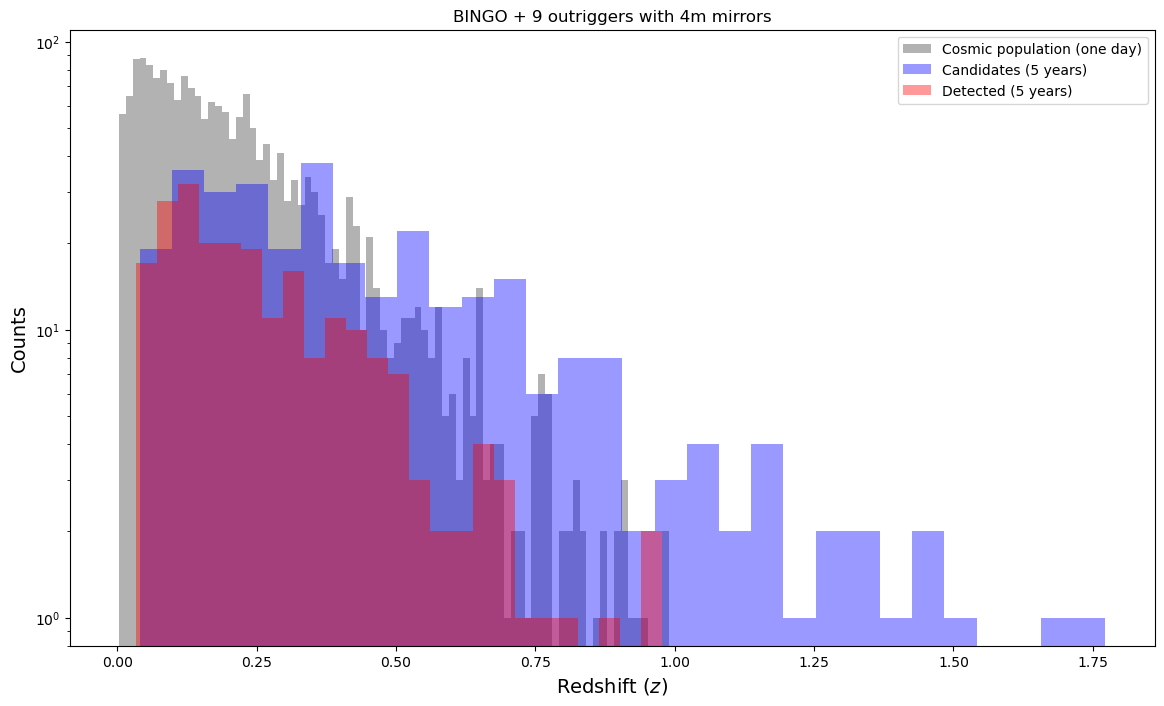

In [8]:
data_path_frb_66 = 'frb_66data.txt'
dm_frb = np.loadtxt(data_path_frb_66, skiprows=1, usecols=range(2, 6))
z_frb = dm_frb[:, 0]

data_path_detec = 'data_sim/DM_EG_detected_bingo+mirror_4m_alpha=-1.5_5yrs.txt'
dm_detec = np.loadtxt(data_path_detec, skiprows=1)
z_dectected = dm_detec[:, 0]

data_path_cand = 'data_sim/DM_EG_candidates_bingo+mirror_4m_alpha=-1.5_5yrs.txt'
dm_cand = np.loadtxt(data_path_cand, skiprows=1)
z_cand = dm_cand[:, 0]

# Generate x values for PDFs
x = np.linspace(min(z_frb), max(z_frb), 1000)

plt.figure(figsize=(14, 8))
# plt.hist(z_frb, bins='auto', alpha=0.4, label='FRB data', color='blue')
plt.hist(z, bins=80, color='gray', alpha=0.6, label='Cosmic population (one day)')
plt.hist(z_cand, bins=30, alpha=0.4, label='Candidates (5 years)', color='blue')
plt.hist(z_dectected, bins=25, alpha=0.4, label='Detected (5 years)', color='red')
plt.title('BINGO + 9 outriggers with 4m mirrors')
# plt.title('No telescope')
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend()
plt.semilogy()
# plt.savefig('mock_no_telescope.png', dpi=600)
plt.savefig('mock_frblip_bingo+4m_mirror.png', dpi=600)

In [9]:
# lumi = frb_data['luminosity_distance']
# plt.hist(lumi, bins=80)
# plt.loglog()
# plt.show()

In [10]:
# densi_flux = frb_data['flux']
# plt.hist(densi_flux, bins=80)
# plt.loglog()
# plt.show()

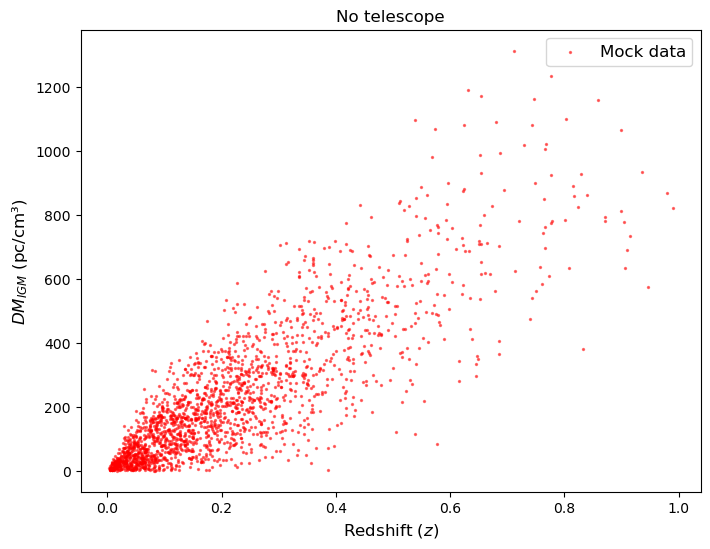

In [11]:
# Plot para o DM_IGM
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_IGM, color='red', alpha=0.5, label='Mock data', marker='o', s=2)
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel('$DM_{IGM}$ (pc/cm³)', fontsize=12)
plt.title(label='No telescope', fontsize=12)
plt.legend(fontsize=12)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
plt.savefig('mock_DM_IGM_no_telescope.png', dpi=600)
plt.show()

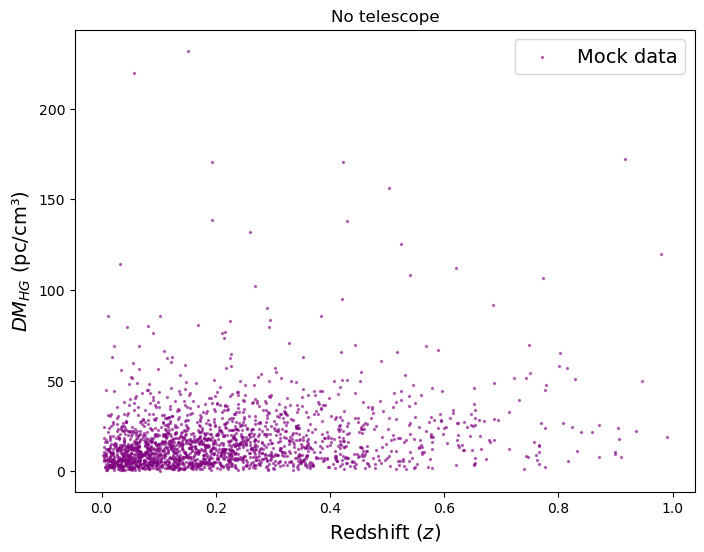

In [12]:
# Plot para o DM_HG
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_HG, color='purple', alpha=0.5, label='Mock data', marker='o', s=2)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{HG}$ (pc/cm³)', fontsize=14)
plt.title(label='No telescope')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
plt.savefig('mock_DM_HG_no_telescope.png', dpi=600)
plt.show()

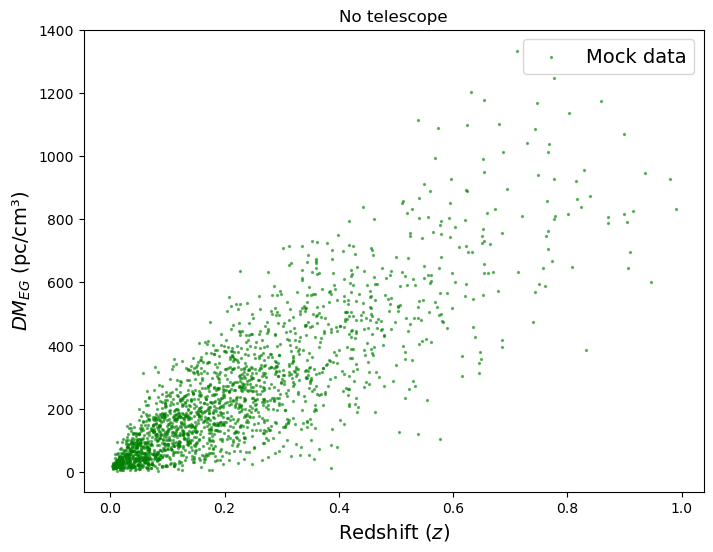

In [13]:
# Plot para o DM_EG
plt.figure(figsize=(8, 6))
plt.scatter(z, DM_EG, color='green', alpha=0.5, label='Mock data', marker='o', s=2)
plt.xlabel('Redshift ($z$)', fontsize=14)
plt.ylabel('$DM_{EG}$ (pc/cm³)', fontsize=14)
plt.title(label='No telescope')
plt.legend(fontsize=14)
#plt.xlim(xmax=1)
#plt.ylim(ymax=1500)
plt.grid(False)
plt.savefig('mock_DM_EG_no_telescope.png', dpi=600)
plt.show()

In [14]:
# Salvando os dados da DM_IGM

# Removendo as unidades
DM_IGM_value = DM_IGM.to_value()  

# Combinando os arrays em duas colunas
data = np.column_stack((z, DM_IGM_value))
#np.savetxt('data_sim/DM_IGM_sim_bingo+mirror_6m.txt', data, fmt='%f', delimiter='\t', header='z\tDM_IGM')

In [15]:
# Salvando os dados da DM_EG
DM_EG_value = DM_EG.to_value()  
data = np.column_stack((z, DM_EG_value))
np.savetxt('/home/zeuscosmos/comba/comba/data/redshift_dist_mock_frblip.txt', data, fmt='%f', delimiter='\t', header='z \t DM_ext')

In [16]:
# # Salvando os dados da DM_HG
# DM_EG_value = DM_HG.to_value() 
# data = np.column_stack((z, DM_EG_value))
# np.savetxt('data_sim/DM_HG_no_telescope.txt', data, fmt='%f', delimiter='\t', header='z\tDM_HG')

In [17]:
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
import astropy.units as u

plt.style.use(astropy_mpl_style)


In [18]:
declination = frb_data['declination']
right_ascension = frb_data['right_ascension']

coords = SkyCoord(ra=right_ascension, dec=declination, frame='icrs')


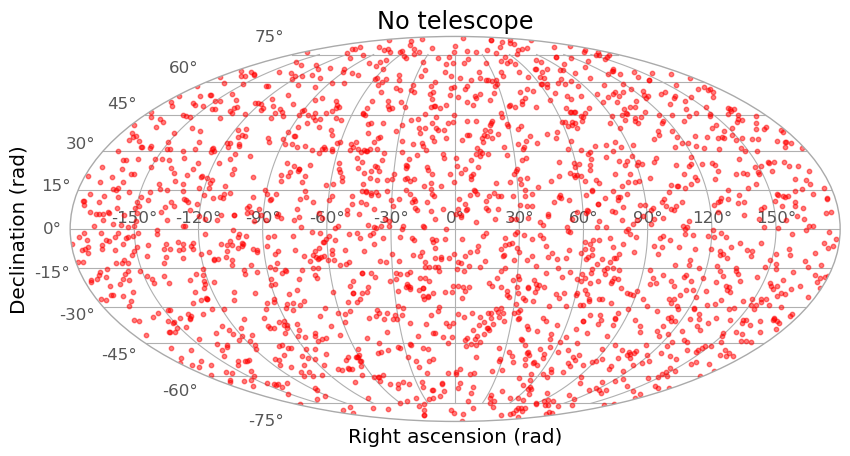

In [19]:
plt.figure(figsize=(10, 5))
plt.subplot(111, projection="mollweide")

# Converter RA para radianos e ajustar para o formato da projeção
ra_rad = coords.ra.wrap_at(180 * u.deg).radian
dec_rad = coords.dec.radian

plt.scatter(ra_rad, dec_rad, color='red', marker='o', s=10, alpha=0.5)
plt.grid(True)

plt.xlabel('Right ascension (rad)')
plt.ylabel('Declination (rad)')
plt.title(label='No telescope')
plt.savefig('sky_map_no_telescope.png', dpi=600)
plt.show()